# 05 - 2025 Monsoon Case Study

This notebook demonstrates applying the benchmark to the 2025 monsoon season:
- Generate forecasts from initialization dates
- Track onset prediction evolution
- Evaluate real-time forecast skill

Reference: Decision-oriented benchmarking to transform AI weather forecast access:
Application to the Indian monsoon

In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd
from datetime import datetime, timedelta
from pathlib import Path

# Import monsoon benchmark modules
from monsoon_benchmark.data.regions import CMZ_BOUNDS, create_target_grid
from monsoon_benchmark.indices import compute_local_onset
from monsoon_benchmark.evaluation import MonsoonBenchmark, generate_init_dates
from monsoon_benchmark.visualization import (
    plot_rainfall_evolution,
    plot_wyi_evolution,
)

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')

## 1. Case Study Setup

Configure the 2025 case study parameters.

In [2]:
# 2025 case study parameters
CASE_YEAR = 2025

# Key dates for 2025 monsoon
MOK_2025 = datetime(2025, 6, 2)  # Expected MOK date (climatological)

# Generate initialization dates (May 2 - June 30)
init_dates_2025 = generate_init_dates(
    year=CASE_YEAR,
    start_date="05-02",
    end_date="06-30",
    frequency='twice_weekly'
)

print(f"2025 Case Study Configuration:")
print(f"  Year: {CASE_YEAR}")
print(f"  Expected MOK: {MOK_2025.strftime('%Y-%m-%d')}")
print(f"  Initialization dates: {len(init_dates_2025)}")
print(f"  First init: {init_dates_2025[0].strftime('%Y-%m-%d')}")
print(f"  Last init: {init_dates_2025[-1].strftime('%Y-%m-%d')}")

2025 Case Study Configuration:
  Year: 2025
  Expected MOK: 2025-06-02
  Initialization dates: 17
  First init: 2025-05-05
  Last init: 2025-06-30


In [3]:
# Target grid cells for detailed analysis
TARGET_CELLS = {
    'Central India': (22.0, 78.0),  # Madhya Pradesh
    'Western Ghats': (14.0, 74.0),  # Karnataka coast
    'CMZ North': (26.0, 82.0),      # Uttar Pradesh
    'CMZ South': (18.0, 78.0),      # Telangana
}

print("\nTarget grid cells for analysis:")
for name, (lat, lon) in TARGET_CELLS.items():
    print(f"  {name}: ({lat}N, {lon}E)")


Target grid cells for analysis:
  Central India: (22.0N, 78.0E)
  Western Ghats: (14.0N, 74.0E)
  CMZ North: (26.0N, 82.0E)
  CMZ South: (18.0N, 78.0E)


## 2. Simulated 2025 Data

For demonstration, create simulated 2025 observations and forecasts.

In [4]:
np.random.seed(2025)

# Create simulated "observed" onset for 2025
# (In practice, this would come from real-time IMD data)

# Simulate a slightly early onset year
observed_onset_2025 = {
    'Central India': datetime(2025, 6, 15),
    'Western Ghats': datetime(2025, 6, 5),
    'CMZ North': datetime(2025, 6, 25),
    'CMZ South': datetime(2025, 6, 12),
}

print("Simulated 2025 observed onset dates:")
for cell, date in observed_onset_2025.items():
    doy = date.timetuple().tm_yday
    print(f"  {cell}: {date.strftime('%b %d')} (DOY {doy})")

Simulated 2025 observed onset dates:
  Central India: Jun 15 (DOY 166)
  Western Ghats: Jun 05 (DOY 156)
  CMZ North: Jun 25 (DOY 176)
  CMZ South: Jun 12 (DOY 163)


In [5]:
# Create simulated rainfall time series for a cell
def create_simulated_rainfall(onset_date, year=2025):
    """Create simulated daily rainfall around onset."""
    # Time range: May 1 to July 31
    dates = pd.date_range(f'{year}-05-01', f'{year}-07-31', freq='D')
    n_days = len(dates)
    
    # Base rainfall pattern
    rainfall = np.zeros(n_days)
    
    # Pre-monsoon: occasional showers
    onset_idx = (onset_date - datetime(year, 5, 1)).days
    
    for i in range(n_days):
        if i < onset_idx - 5:
            # Pre-monsoon
            if np.random.random() < 0.1:
                rainfall[i] = np.random.exponential(5)
        elif i < onset_idx:
            # Transition
            if np.random.random() < 0.3:
                rainfall[i] = np.random.exponential(8)
        else:
            # Monsoon active
            if np.random.random() < 0.7:
                rainfall[i] = np.random.exponential(15) + 2
    
    return xr.DataArray(
        rainfall,
        dims=['time'],
        coords={'time': dates},
        name='rainfall'
    )

# Generate rainfall for target cells
simulated_rainfall = {}
for cell, onset in observed_onset_2025.items():
    simulated_rainfall[cell] = create_simulated_rainfall(onset)

print("Generated simulated rainfall time series")

Generated simulated rainfall time series


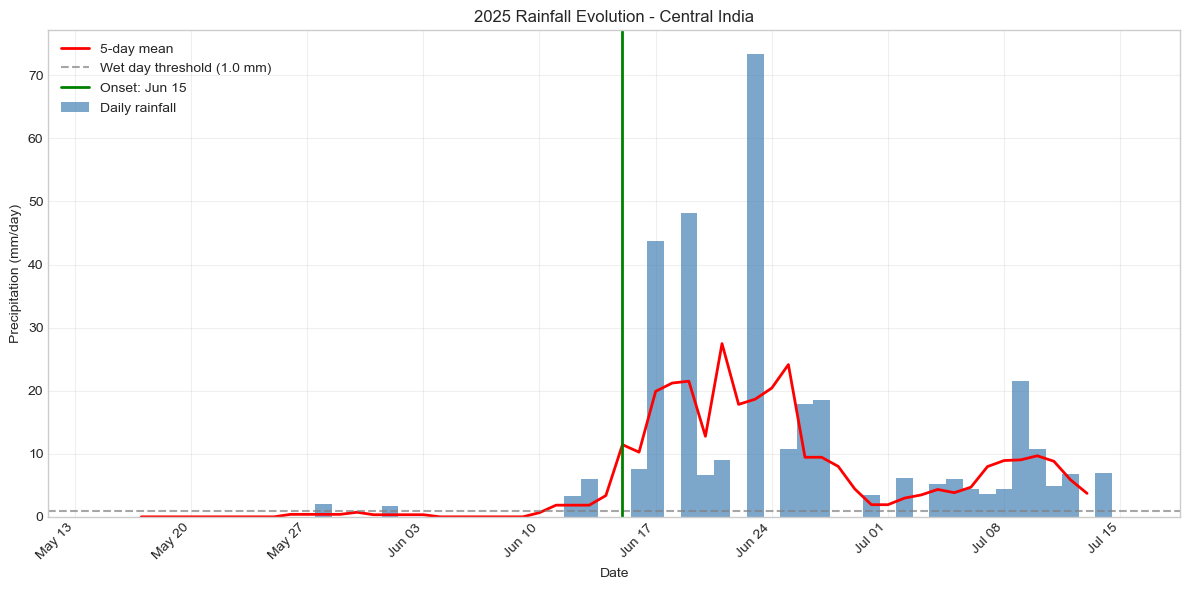

In [6]:
# Plot rainfall evolution for Central India
cell_name = 'Central India'
lat, lon = TARGET_CELLS[cell_name]
precip = simulated_rainfall[cell_name].sel(
    time=slice('2025-05-15', '2025-07-15')
)

fig = plot_rainfall_evolution(
    precip,
    onset_date=observed_onset_2025[cell_name],
    lat=lat,
    lon=lon,
    year=2025,
    title=f'2025 Rainfall Evolution - {cell_name}'
)
plt.show()

## 3. Simulated Ensemble Forecasts

Create simulated ensemble forecasts for multiple models.

In [7]:
def generate_ensemble_forecast_onsets(
    observed_onset,
    init_date,
    ensemble_size=51,
    bias=0,
    spread=5
):
    """
    Generate simulated ensemble onset dates.
    
    Returns list of onset dates (or None for no-onset members)
    """
    onsets = []
    obs_doy = observed_onset.timetuple().tm_yday
    
    for m in range(ensemble_size):
        # Add bias and spread to observed
        member_doy = obs_doy + bias + np.random.normal(0, spread)
        
        # Some members might predict no onset (after day 200)
        if member_doy > 200 or member_doy < 150:
            if np.random.random() < 0.1:
                onsets.append(None)
                continue
        
        member_date = datetime(2025, 1, 1) + timedelta(days=int(member_doy) - 1)
        onsets.append(member_date)
    
    return onsets

# Generate forecasts for different models at a sample init date
sample_init = datetime(2025, 6, 2)  # June 2 initialization
cell = 'Central India'
obs_onset = observed_onset_2025[cell]

model_forecasts = {
    'GenCast': generate_ensemble_forecast_onsets(obs_onset, sample_init, bias=0, spread=4),
    'AIFS-ENS': generate_ensemble_forecast_onsets(obs_onset, sample_init, bias=1, spread=5),
    'IFS-ENS': generate_ensemble_forecast_onsets(obs_onset, sample_init, bias=2, spread=6),
    'FuXi-S2S': generate_ensemble_forecast_onsets(obs_onset, sample_init, bias=-1, spread=5),
}

print(f"Generated ensemble forecasts for init date: {sample_init.strftime('%Y-%m-%d')}")
print(f"Observed onset: {obs_onset.strftime('%b %d')}")
print(f"\nEnsemble summary:")
for model, onsets in model_forecasts.items():
    valid = [o for o in onsets if o is not None]
    if valid:
        mean_date = datetime(2025, 1, 1) + timedelta(
            days=int(np.mean([o.timetuple().tm_yday for o in valid])) - 1
        )
        print(f"  {model}: {len(valid)}/{len(onsets)} members, mean={mean_date.strftime('%b %d')}")
    else:
        print(f"  {model}: No valid onset predictions")

Generated ensemble forecasts for init date: 2025-06-02
Observed onset: Jun 15

Ensemble summary:
  GenCast: 51/51 members, mean=Jun 15
  AIFS-ENS: 51/51 members, mean=Jun 14
  IFS-ENS: 51/51 members, mean=Jun 16
  FuXi-S2S: 51/51 members, mean=Jun 13


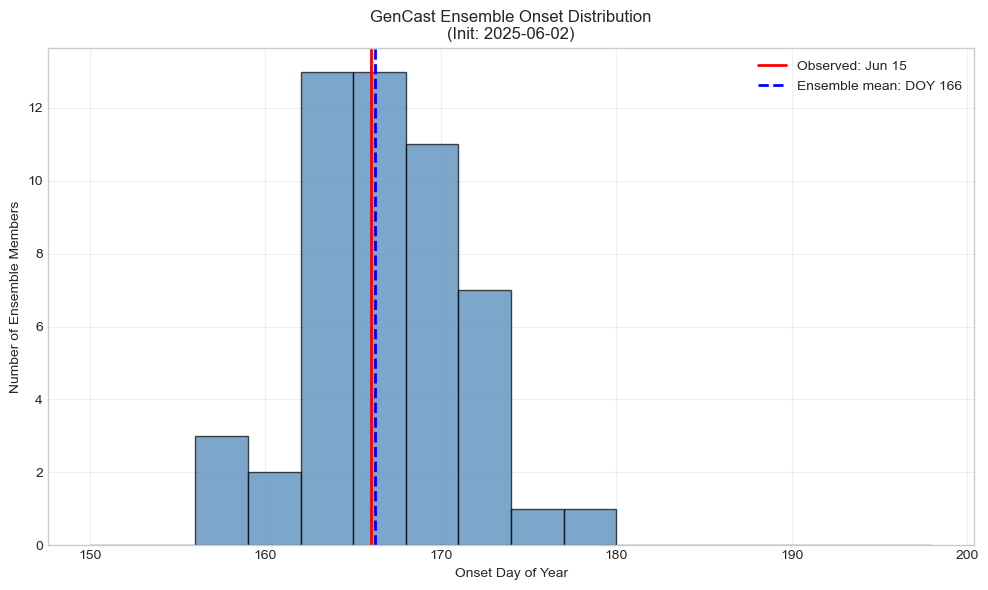

In [8]:
# Plot ensemble spread for GenCast
fig, ax = plt.subplots(figsize=(10, 6))

# Get valid onset dates
valid_onsets = [o for o in model_forecasts['GenCast'] if o is not None]
valid_doys = [o.timetuple().tm_yday for o in valid_onsets]

# Histogram of ensemble onset DOYs
ax.hist(valid_doys, bins=range(150, 200, 3), alpha=0.7, color='steelblue', edgecolor='black')

# Observed onset
obs_doy = obs_onset.timetuple().tm_yday
ax.axvline(obs_doy, color='red', linewidth=2, linestyle='-', label=f'Observed: {obs_onset.strftime("%b %d")}')

# Ensemble mean
mean_doy = np.mean(valid_doys)
ax.axvline(mean_doy, color='blue', linewidth=2, linestyle='--', label=f'Ensemble mean: DOY {mean_doy:.0f}')

ax.set_xlabel('Onset Day of Year')
ax.set_ylabel('Number of Ensemble Members')
ax.set_title(f'GenCast Ensemble Onset Distribution\n(Init: {sample_init.strftime("%Y-%m-%d")})')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Forecast Evolution Over Time

Track how onset predictions evolve as initialization dates approach onset.

In [9]:
# Track forecast evolution for Central India
cell = 'Central India'
obs_onset = observed_onset_2025[cell]

# Select init dates from May 8 to June 12
selected_inits = [d for d in init_dates_2025 
                  if datetime(2025, 5, 8) <= d <= datetime(2025, 6, 12)]

# Generate forecast evolution for GenCast
forecast_evolution = {}

for init_date in selected_inits:
    lead_days = (obs_onset - init_date).days
    
    # Skill improves as lead time decreases
    spread = max(3, lead_days / 5)
    bias = lead_days / 15  # Small positive bias at long leads
    
    ensemble_onsets = generate_ensemble_forecast_onsets(
        obs_onset, init_date, 
        ensemble_size=51, 
        bias=bias, 
        spread=spread
    )
    
    valid_onsets = [o for o in ensemble_onsets if o is not None]
    if valid_onsets:
        mean_doy = np.mean([o.timetuple().tm_yday for o in valid_onsets])
        std_doy = np.std([o.timetuple().tm_yday for o in valid_onsets])
    else:
        mean_doy = np.nan
        std_doy = np.nan
    
    forecast_evolution[init_date] = {
        'mean_doy': mean_doy,
        'std_doy': std_doy,
        'n_valid': len(valid_onsets),
        'lead_days': lead_days,
    }

print("Forecast evolution computed")

Forecast evolution computed


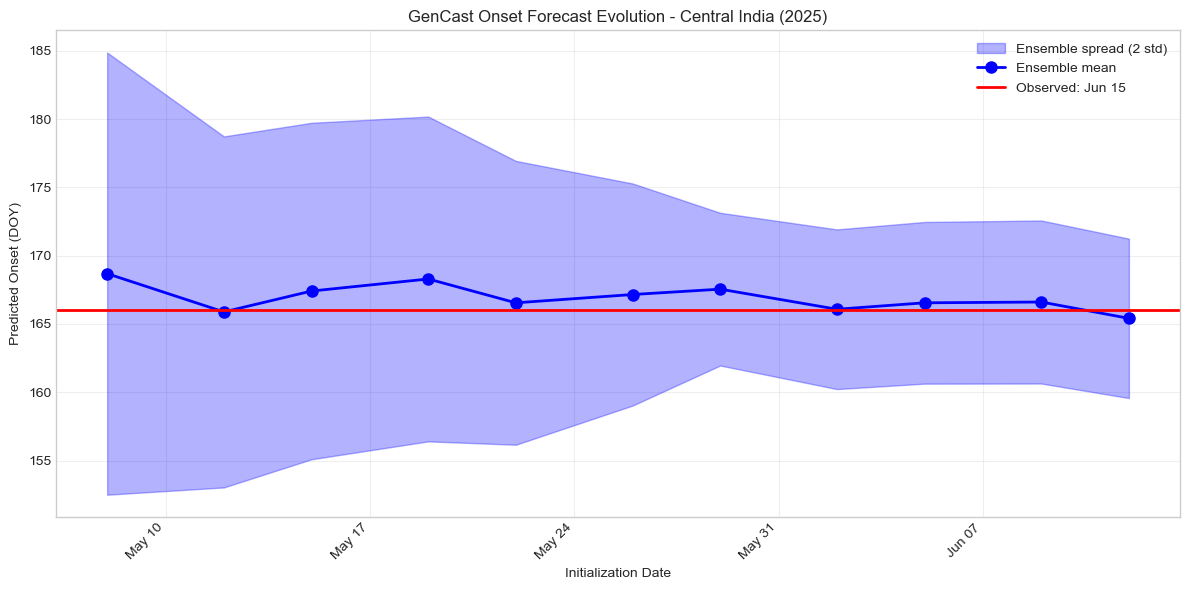

In [10]:
# Plot forecast evolution
fig, ax = plt.subplots(figsize=(12, 6))

init_dates_plot = list(forecast_evolution.keys())
mean_doys = [forecast_evolution[d]['mean_doy'] for d in init_dates_plot]
std_doys = [forecast_evolution[d]['std_doy'] for d in init_dates_plot]

# Plot forecast mean with uncertainty
mean_doys = np.array(mean_doys)
std_doys = np.array(std_doys)

ax.fill_between(
    init_dates_plot,
    mean_doys - 2*std_doys,
    mean_doys + 2*std_doys,
    alpha=0.3,
    color='blue',
    label='Ensemble spread (2 std)'
)
ax.plot(init_dates_plot, mean_doys, 'b-o', linewidth=2, markersize=8, label='Ensemble mean')

# Observed onset
obs_doy = obs_onset.timetuple().tm_yday
ax.axhline(obs_doy, color='red', linestyle='-', linewidth=2, label=f'Observed: {obs_onset.strftime("%b %d")}')

ax.set_xlabel('Initialization Date')
ax.set_ylabel('Predicted Onset (DOY)')
ax.set_title(f'GenCast Onset Forecast Evolution - {cell} (2025)')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

# Format x-axis
import matplotlib.dates as mdates
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=7))
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

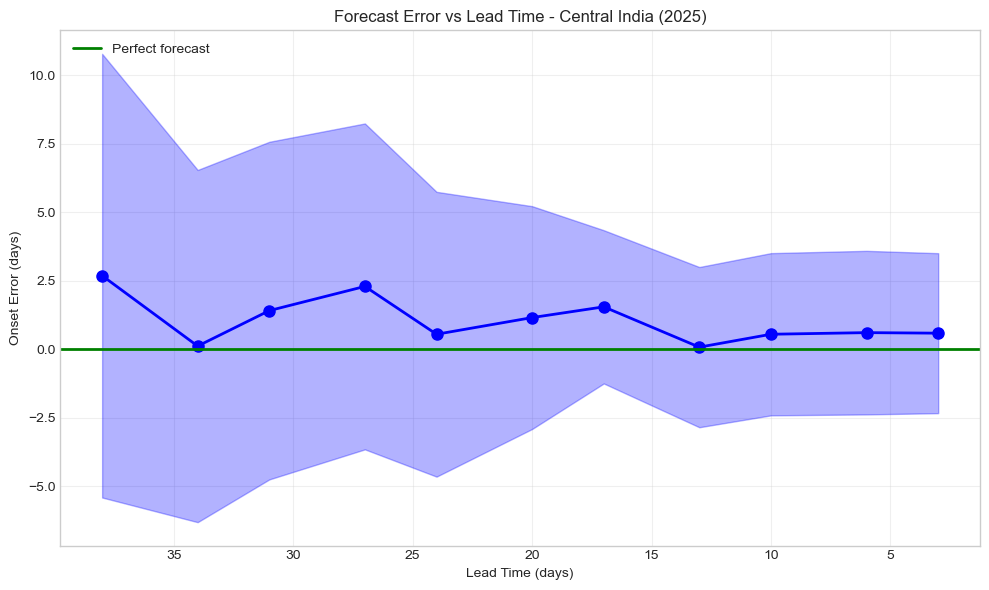

In [11]:
# Convert to lead time view
fig, ax = plt.subplots(figsize=(10, 6))

lead_days_arr = [forecast_evolution[d]['lead_days'] for d in init_dates_plot]
errors = np.abs(mean_doys - obs_doy)

ax.fill_between(
    lead_days_arr,
    errors - std_doys,
    errors + std_doys,
    alpha=0.3,
    color='blue'
)
ax.plot(lead_days_arr, errors, 'b-o', linewidth=2, markersize=8)

ax.axhline(0, color='green', linestyle='-', linewidth=2, label='Perfect forecast')

ax.set_xlabel('Lead Time (days)')
ax.set_ylabel('Onset Error (days)')
ax.set_title(f'Forecast Error vs Lead Time - {cell} (2025)')
ax.invert_xaxis()  # Larger lead times on left
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Multi-Model Comparison for 2025

In [12]:
# Compare models at a fixed init date
fixed_init = datetime(2025, 6, 5)

models_comparison = {
    'GenCast': {'bias': 0, 'spread': 4},
    'AIFS-ENS': {'bias': 1, 'spread': 5},
    'IFS-ENS': {'bias': 2, 'spread': 7},
    'FuXi-S2S': {'bias': -1, 'spread': 6},
}

results_2025 = {}

for cell_name, (lat, lon) in TARGET_CELLS.items():
    obs_onset = observed_onset_2025[cell_name]
    obs_doy = obs_onset.timetuple().tm_yday
    
    cell_results = {'observed': obs_onset}
    
    for model, params in models_comparison.items():
        onsets = generate_ensemble_forecast_onsets(
            obs_onset, fixed_init,
            ensemble_size=51,
            **params
        )
        
        valid = [o for o in onsets if o is not None]
        if valid:
            mean_doy = np.mean([o.timetuple().tm_yday for o in valid])
            error = mean_doy - obs_doy
        else:
            mean_doy = np.nan
            error = np.nan
        
        cell_results[model] = {
            'mean_doy': mean_doy,
            'error': error,
            'n_valid': len(valid),
        }
    
    results_2025[cell_name] = cell_results

# Display results
print(f"\n2025 Case Study Results (Init: {fixed_init.strftime('%Y-%m-%d')})")
print("=" * 70)

for cell_name, results in results_2025.items():
    obs = results['observed']
    print(f"\n{cell_name} (Observed: {obs.strftime('%b %d')}):")
    for model in models_comparison.keys():
        r = results[model]
        if not np.isnan(r['error']):
            print(f"  {model:12s}: Error = {r['error']:+.1f} days")
        else:
            print(f"  {model:12s}: No valid prediction")


2025 Case Study Results (Init: 2025-06-05)

Central India (Observed: Jun 15):
  GenCast     : Error = -0.6 days
  AIFS-ENS    : Error = +0.6 days
  IFS-ENS     : Error = +2.2 days
  FuXi-S2S    : Error = -1.8 days

Western Ghats (Observed: Jun 05):
  GenCast     : Error = -1.2 days
  AIFS-ENS    : Error = +1.1 days
  IFS-ENS     : Error = +1.9 days
  FuXi-S2S    : Error = -1.6 days

CMZ North (Observed: Jun 25):
  GenCast     : Error = -0.3 days
  AIFS-ENS    : Error = -0.4 days
  IFS-ENS     : Error = +2.4 days
  FuXi-S2S    : Error = -0.8 days

CMZ South (Observed: Jun 12):
  GenCast     : Error = -0.8 days
  AIFS-ENS    : Error = +0.9 days
  IFS-ENS     : Error = +0.3 days
  FuXi-S2S    : Error = -1.8 days


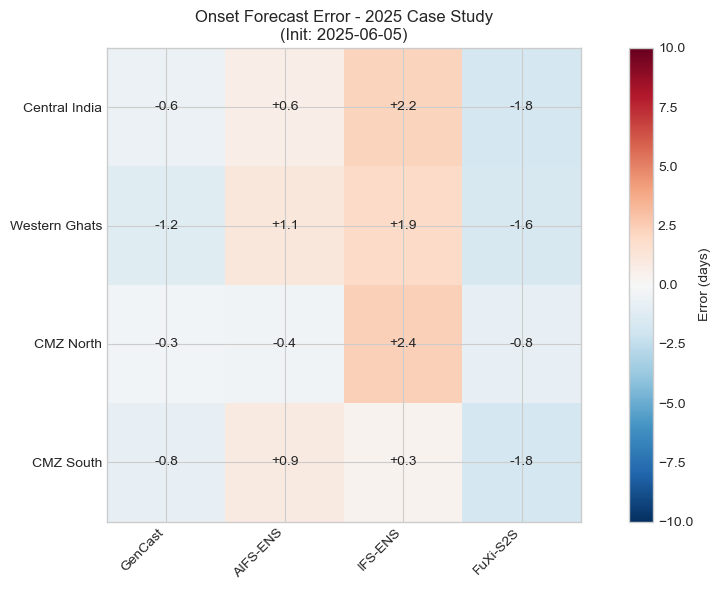

In [13]:
# Heatmap of errors
cells = list(TARGET_CELLS.keys())
models = list(models_comparison.keys())

error_matrix = np.zeros((len(cells), len(models)))

for i, cell in enumerate(cells):
    for j, model in enumerate(models):
        error_matrix[i, j] = results_2025[cell][model]['error']

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(error_matrix, cmap='RdBu_r', vmin=-10, vmax=10)

ax.set_xticks(range(len(models)))
ax.set_xticklabels(models, rotation=45, ha='right')
ax.set_yticks(range(len(cells)))
ax.set_yticklabels(cells)

# Add text annotations
for i in range(len(cells)):
    for j in range(len(models)):
        text = f"{error_matrix[i, j]:+.1f}"
        ax.text(j, i, text, ha='center', va='center', fontsize=10)

plt.colorbar(im, ax=ax, label='Error (days)')
ax.set_title(f'Onset Forecast Error - 2025 Case Study\n(Init: {fixed_init.strftime("%Y-%m-%d")})')

plt.tight_layout()
plt.show()

## 6. Operational Recommendations

In [14]:
# Compute overall model statistics
model_stats = {}

for model in models_comparison.keys():
    errors = [results_2025[cell][model]['error'] for cell in cells]
    errors = [e for e in errors if not np.isnan(e)]
    
    if errors:
        model_stats[model] = {
            'MAE': np.mean(np.abs(errors)),
            'Bias': np.mean(errors),
            'RMSE': np.sqrt(np.mean(np.array(errors)**2)),
        }

print("\n2025 Case Study - Model Summary Statistics")
print("=" * 50)
print(f"{'Model':<15} {'MAE':>10} {'Bias':>10} {'RMSE':>10}")
print("-" * 50)

for model, stats in sorted(model_stats.items(), key=lambda x: x[1]['MAE']):
    print(f"{model:<15} {stats['MAE']:>10.1f} {stats['Bias']:>+10.1f} {stats['RMSE']:>10.1f}")


2025 Case Study - Model Summary Statistics
Model                  MAE       Bias       RMSE
--------------------------------------------------
GenCast                0.7       -0.7        0.8
AIFS-ENS               0.8       +0.6        0.8
FuXi-S2S               1.5       -1.5        1.5
IFS-ENS                1.7       +1.7        1.9


In [15]:
print("\n" + "=" * 60)
print("OPERATIONAL RECOMMENDATIONS FOR 2025 MONSOON")
print("=" * 60)

best_model = min(model_stats.keys(), key=lambda m: model_stats[m]['MAE'])

print(f"\n1. Best performing model: {best_model}")
print(f"   - MAE: {model_stats[best_model]['MAE']:.1f} days")
print(f"   - Bias: {model_stats[best_model]['Bias']:+.1f} days")

print(f"\n2. Regional considerations:")
for cell_name in cells:
    best_for_cell = min(
        models_comparison.keys(),
        key=lambda m: abs(results_2025[cell_name][m]['error'])
    )
    error = results_2025[cell_name][best_for_cell]['error']
    print(f"   - {cell_name}: {best_for_cell} (error: {error:+.1f} days)")

print(f"\n3. Key takeaways:")
print(f"   - Ensemble forecasts provide valuable uncertainty estimates")
print(f"   - Skill improves significantly within 2-week lead time")
print(f"   - Regional performance varies across models")
print(f"   - Consider multi-model ensemble for operational decisions")


OPERATIONAL RECOMMENDATIONS FOR 2025 MONSOON

1. Best performing model: GenCast
   - MAE: 0.7 days
   - Bias: -0.7 days

2. Regional considerations:
   - Central India: GenCast (error: -0.6 days)
   - Western Ghats: AIFS-ENS (error: +1.1 days)
   - CMZ North: GenCast (error: -0.3 days)
   - CMZ South: IFS-ENS (error: +0.3 days)

3. Key takeaways:
   - Ensemble forecasts provide valuable uncertainty estimates
   - Skill improves significantly within 2-week lead time
   - Regional performance varies across models
   - Consider multi-model ensemble for operational decisions


## Summary

This case study demonstrated:

1. **Real-time application** of the benchmark framework to 2025
2. **Forecast evolution tracking** as initialization approaches onset
3. **Multi-model comparison** for specific grid cells
4. **Operational guidance** for agricultural planning

The benchmark enables decision-makers to:
- Choose the most reliable model for their region
- Understand forecast uncertainty
- Make informed crop management decisions